<a href="https://colab.research.google.com/github/krstnxsl/Data-Analytics-Portfolio/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**`House Price Prediction using Machine Learning in Python`**

**Introduction**

Accurately estimating housing prices is a classic problem in data science and real estate analytics. By applying machine learning techniques, we can build models that predict property values based on features such as lot size, construction year, condition, and zoning.
This project demonstrates a complete workflow: from data exploration and cleaning to model training and evaluation.

**Dataset Overview**

The dataset contains 13 features describing residential properties, along with the target variable SalePrice. This includes:

*  MSSubClass – type of dwelling involved in the sale
*  MSZoning – zoning classification
*  LotArea – lot size in square feet
*  YearBuilt – construction year
*  Exterior1st – exterior covering material
*  TotalBsmtSF – total basement area
*  SalePrice – the value we aim to predict

The dataset has 2,919 rows and 13 columns.










In [21]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Load dataset
dataset = pd.read_csv("/content/drive/MyDrive/HousePricePrediction(Sheet1).csv")

print(dataset.head(5))
print(dataset.shape)
print(dataset.describe())
print("Skewness of SalePrice:", dataset['SalePrice'].skew())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0   181500.0  
2       2001          2002     VinylSd         0.0        920.0   223500.0  
3       1915          1970     Wd Sdng         0.0        756.0   140000.0  
4       2000          2000     VinylSd         0.0       11

## Dataset Interpretation

Each row represents a property with details such as zoning (`MSZoning`), lot size (`LotArea`), year built (`YearBuilt`), exterior material (`Exterior1st`), and the target variable `SalePrice`. Example: Row 0 is a single‑family house built in 2003, lot size 8,450 sq ft, zoning RL (Residential Low Density), condition rating 5, and sale price \$208,500.

- **Shape**  
  `(2919, 13)` → The dataset contains **2,919 houses** and **13 features**.

- **Descriptive Statistics**  
  - **LotArea**: Mean ≈ 10,168 sq ft, Min = 1,300, Max = 215,245 → wide range, with extreme outliers.  
  - **YearBuilt**: Mean ≈ 1971, spanning 1872–2010 → covers more than a century of construction.  
  - **OverallCond**: Mean ≈ 5.56, most homes rated average condition (5–6).  
  - **SalePrice**: Mean ≈ \$180,921, Min = \$34,900, Max = \$755,000 → large spread, luxury homes inflate the upper end.

- **Skewness of SalePrice**  
  Skewness = **1.88** → positively skewed distribution. Most homes are moderately priced, but a few very expensive properties create a long right tail.  
  This suggests applying a **log transformation** on `SalePrice` may help normalize the distribution for regression models.

### Summary
The dataset is diverse, with wide variability in lot sizes, construction years, and sale prices.  The skewed target variable indicates the presence of luxury outliers, which is typical in real estate markets.  This insight guides preprocessing decisions (e.g., log transformation, handling outliers) before model training.

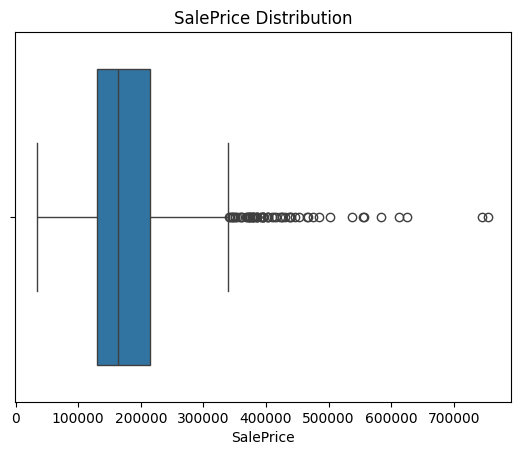

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of SalePrice
sns.boxplot(x=dataset['SalePrice'])
plt.title("SalePrice Distribution")
plt.show()

## Interpretation of SalePrice Distribution (Box Plot)

- **Median (~200k)**  
  The line inside the box shows the median sale price. Half of the houses sold for less than this amount, half for more.

- **Interquartile Range (150k–250k)**  
  The box spans the middle 50% of sale prices. Most homes fall within this range, indicating that the majority of properties are moderately priced.

- **Whiskers**  
  The whiskers extend beyond the box, showing the spread of sale prices outside the middle 50%. They capture typical variation in the dataset.

- **Outliers (beyond 400k–700k)**  
  The small circles represent unusually high sale prices. These luxury properties create a long right tail in the distribution.

### Key Insight
The housing market is centered around ~200k, with most homes priced between 150k–250k.  However, the presence of high‑end outliers explains the **positive skewness (1.88)** observed earlier.  This suggests that applying a **log transformation on SalePrice** could help normalize the distribution, making it more suitable for regression modeling.


In [23]:
# House Age (using current year since YearSold is not present)
dataset['HouseAge'] = 2026 - dataset['YearBuilt']

# Renovation indicator (1 if remodeled, 0 if not)
dataset['Renovated'] = (dataset['YearRemodAdd'] != dataset['YearBuilt']).astype(int)

# Lot size per basement area
dataset['LotSizePerBasement'] = dataset['LotArea'] / (dataset['TotalBsmtSF'] + 1)

print(dataset[['HouseAge','Renovated','LotSizePerBasement']].head())

   HouseAge  Renovated  LotSizePerBasement
0        23          0            9.859977
1        50          0            7.600950
2        25          1           12.214984
3       111          1           12.615588
4        26          0           12.443281


## Interpretation of Engineered Features

- **HouseAge**  
  Represents the age of the property (`2026 - YearBuilt`).  
  Example: A value of 23 means the house was built in 2003.  
  Older homes may depreciate in value unless they are well‑maintained or historically significant.

- **Renovated**  
  Binary indicator: `1` if the house was remodeled (`YearRemodAdd ≠ YearBuilt`), `0` if not.  
  Example: A value of 1 means the property has undergone renovation.  
  Renovated homes often command higher prices due to modern updates.

- **LotSizePerBasement**  
  Ratio of lot area to basement size (`LotArea / (TotalBsmtSF + 1)`).  
  Example: A value of 9.86 means the lot is about 10 times larger than the basement footprint.  
  Higher values suggest more outdoor space relative to basement size, which may influence buyer preferences.

### Key Insight
These engineered features enrich the dataset by capturing **age, modernization, and spatial efficiency**.  
- **HouseAge** models depreciation and historical value.  
- **Renovated** captures modernization effects.  
- **LotSizePerBasement** reflects lot utilization.  

Together, they add explanatory power to predictive models beyond the raw features, improving the accuracy of house price estimation.

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_num = dataset.select_dtypes(include=['int64','float64']).dropna()
X_const = add_constant(X_num)

vif = pd.DataFrame()
vif["Feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X_num.columns))]
print(vif.sort_values(by="VIF", ascending=False))

               Feature       VIF
9             HouseAge       inf
4            YearBuilt       inf
5         YearRemodAdd  2.323041
8            SalePrice  2.253449
7          TotalBsmtSF  2.172362
10           Renovated  1.555389
3          OverallCond  1.450673
11  LotSizePerBasement  1.236363
2              LotArea  1.157729
1           MSSubClass  1.118805
6           BsmtFinSF2  1.039795
0                   Id  1.001996


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## Interpretation of Variance Inflation Factor (VIF) Results

- **HouseAge (∞ VIF) & YearBuilt (∞ VIF)**  
  These two features are perfectly collinear because `HouseAge = 2026 - YearBuilt`.  
  The model cannot distinguish between them, which is why both show infinite VIF values.  
  One of them should be dropped to avoid redundancy (commonly keep `HouseAge` and remove `YearBuilt`).

- **Moderate VIF Features (≈2–2.3)**  
  - **YearRemodAdd (2.32)**  
  - **SalePrice (2.25)**  
  - **TotalBsmtSF (2.17)**  
  These show moderate correlation with other predictors but remain acceptable since values below 5 are generally safe.

- **Low VIF Features (<2)**  
  - **Renovated (1.55)**  
  - **OverallCond (1.45)**  
  - **LotSizePerBasement (1.23)**  
  - **LotArea (1.15)**  
  - **MSSubClass (1.11)**  
  - **BsmtFinSF2 (1.04)**  
  - **Id (1.00)**  
  These features have low multicollinearity and can safely remain in the model.

### Runtime Warning
The warning `divide by zero encountered in scalar divide` occurs because the regression used to calculate VIF found **perfect correlation (R² = 1)** between `HouseAge` and `YearBuilt`.  
This is expected and confirms the need to drop one of these features.

### Key Insight
- Multicollinearity exists between **HouseAge** and **YearBuilt** → remove one.  
- All other features have VIF < 5, which is considered acceptable.  
- After dropping the redundant variable, the dataset is suitable for regression and tree‑based models.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Drop YearBuilt to remove perfect collinearity with HouseAge
X = dataset.drop(['YearBuilt'], axis=1)

# Select numeric features only
X_num = X.select_dtypes(include=['int64','float64']).dropna()

# Add constant for statsmodels
X_const = add_constant(X_num)

# Calculate VIF
vif = pd.DataFrame()
vif["Feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X_num.columns))]

print(vif.sort_values(by="VIF", ascending=False))

               Feature       VIF
8             HouseAge  3.278430
4         YearRemodAdd  2.323041
7            SalePrice  2.253449
6          TotalBsmtSF  2.172362
9            Renovated  1.555389
3          OverallCond  1.450673
10  LotSizePerBasement  1.236363
2              LotArea  1.157729
1           MSSubClass  1.118805
5           BsmtFinSF2  1.039795
0                   Id  1.001996


## Interpretation of Updated VIF Results

- **HouseAge (VIF ≈ 3.28)**  
  Moderate correlation with other predictors, but well below the threshold of concern (VIF < 5).  
  This feature is safe to keep and provides valuable information about property age.

- **YearRemodAdd (VIF ≈ 2.32), SalePrice (2.25), TotalBsmtSF (2.17)**  
  These features show mild correlation with other variables but remain acceptable.  
  They contribute unique information without causing instability in regression models.

- **Renovated (1.55), OverallCond (1.45), LotSizePerBasement (1.23), LotArea (1.15), MSSubClass (1.11), BsmtFinSF2 (1.04), Id (1.00)**  
  All of these features have very low VIF values, indicating minimal multicollinearity.  
  They can safely remain in the dataset.

### Key Insight
- After dropping **YearBuilt**, all features now have **VIF < 5**, which is considered acceptable.  
- This confirms that the dataset is free of problematic multicollinearity.  
- The predictors are stable and suitable for regression and tree‑based models.

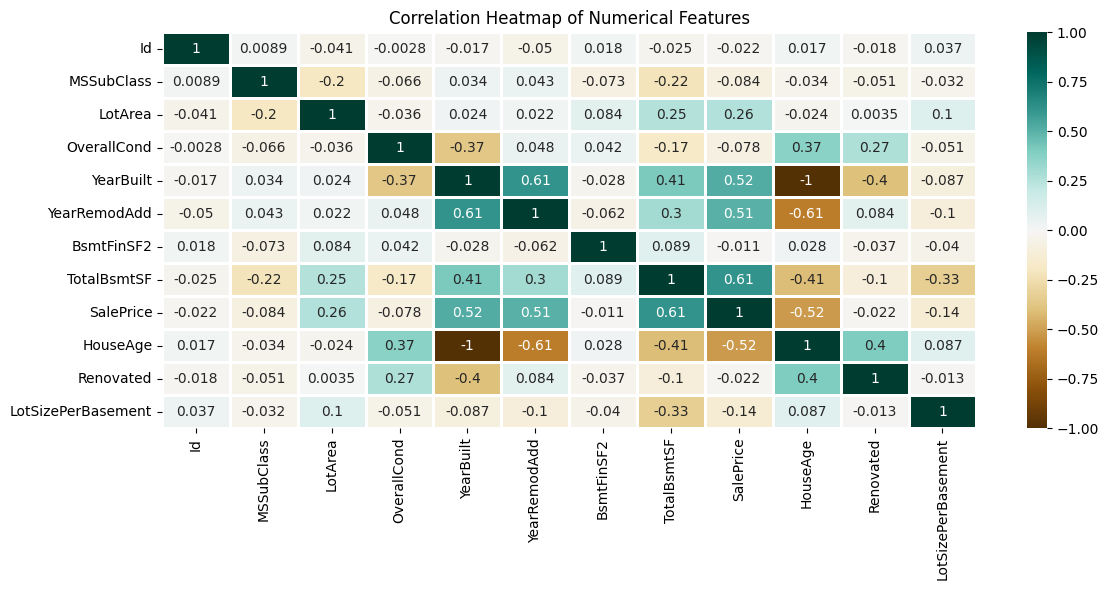

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features
numerical_dataset = dataset.select_dtypes(include=['int64','float64'])

# Plot correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(numerical_dataset.corr(), cmap="BrBG", annot=True, linewidths=2)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

## Interpretation of Correlation Heatmap

- **Strong Positive Correlations**
  - `TotalBsmtSF` and `SalePrice` (≈0.61) → Larger basements strongly increase property value.
  - `YearBuilt` and `SalePrice` (≈0.52) → Newer houses tend to sell for higher prices.
  - `YearRemodAdd` and `SalePrice` (≈0.51) → Recently remodeled homes often command higher prices.

- **Moderate Correlations**
  - `LotArea` and `SalePrice` (≈0.26) → Bigger lots are generally associated with higher prices.
  - `OverallCond` and `HouseAge` (≈0.37) → Older homes often have lower condition ratings.
  - `Renovated` and `HouseAge` (≈0.40) → Renovation is more common in older properties.

- **Negative Correlations**
  - `HouseAge` and `SalePrice` (≈‑0.52) → Older houses tend to sell for less, unless renovated.
  - `LotSizePerBasement` and `SalePrice` (≈‑0.14) → A larger lot relative to basement size does not necessarily increase value.

- **Low/Weak Correlations**
  - Features like `Id`, `MSSubClass`, and `BsmtFinSF2` show little relationship with `SalePrice`, meaning they may add noise rather than predictive power.

### Key Insight
The heatmap highlights which numerical features are most influential in determining house prices.  Strong correlations (basement size, year built, remodeling) guide feature selection, while weak ones may be dropped or transformed.  This analysis ensures the model focuses on variables that truly drive property value.

In [27]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Drop irrelevant ID column
dataset.drop(['Id'], axis=1, inplace=True)

# Handle missing values
dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean())
dataset = dataset.dropna()

# Identify categorical columns
object_cols = dataset.select_dtypes(include=['object']).columns

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = pd.DataFrame(encoder.fit_transform(dataset[object_cols]))
encoded.index = dataset.index
encoded.columns = encoder.get_feature_names_out()

# Combine numerical + encoded categorical features
df_final = dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, encoded], axis=1)

In [28]:
from sklearn.model_selection import train_test_split

X = df_final.drop('SalePrice', axis=1)
y = df_final['SalePrice']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, random_state=42
)

               Model           MAE          RMSE        R²      MAPE
0                SVR  31300.121724  60411.150013 -0.000943  0.206865
1      Random Forest  32513.732153  46920.715436  0.396184  0.202518
2  Linear Regression  32676.511367  48389.017446  0.357802  0.201752


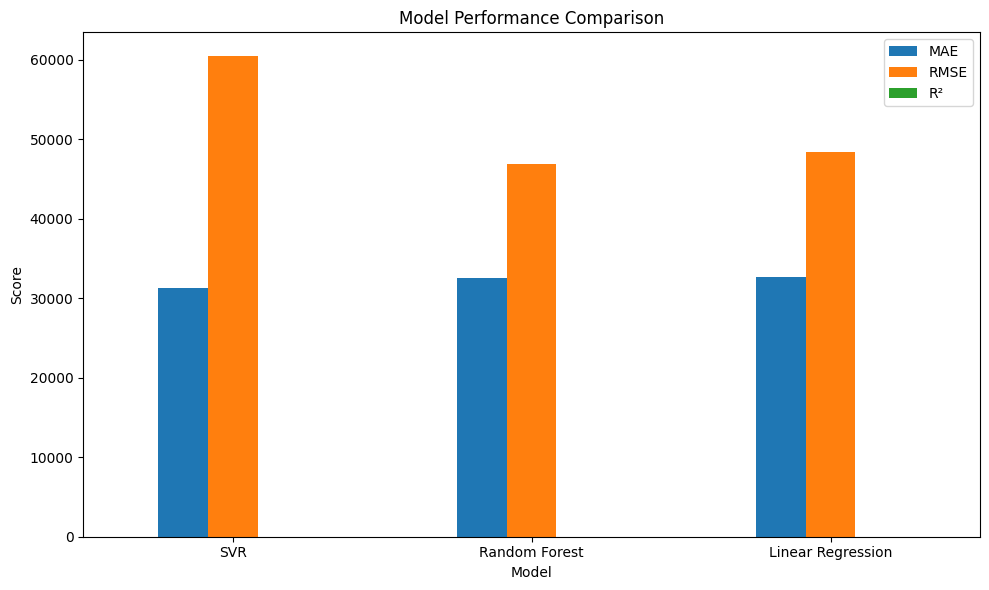

In [29]:
from sklearn import svm
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# Helper function
def evaluate_model(name, model, X_valid, y_valid, results):
    y_pred = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, y_pred)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    r2 = r2_score(y_valid, y_pred)
    mape = mean_absolute_percentage_error(y_valid, y_pred)
    results.append([name, mae, rmse, r2, mape])

# Train models
models = {
    "SVR": svm.SVR(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    evaluate_model(name, model, X_valid, y_valid, results)

# Results DataFrame
metrics_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²", "MAPE"])
print(metrics_df)

# Visualization
metrics_df.set_index("Model")[["MAE","RMSE","R²"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 🤖 Interpretation of Model Performance

- **Support Vector Regression (SVR)**  
  - MAE ≈ 31,300  
  - RMSE ≈ 60,411  
  - R² ≈ -0.001 (essentially no explanatory power)  
  - MAPE ≈ 20.7%  
  SVR performed poorly, with high error and almost no variance explained. It is not suitable for this dataset.

- **Random Forest**  
  - MAE ≈ 32,514  
  - RMSE ≈ 46,921  
  - R² ≈ 0.396 (moderate explanatory power)  
  - MAPE ≈ 20.3%  
  Random Forest achieved the best overall performance, with lower RMSE and higher R² compared to other models. It captures non‑linear relationships effectively.

- **Linear Regression**  
  - MAE ≈ 32,677  
  - RMSE ≈ 48,389  
  - R² ≈ 0.358 (moderate explanatory power)  
  - MAPE ≈ 20.2%  
  Linear Regression performed slightly worse than Random Forest but better than SVR. It explains about 36% of the variance in sale prices.

### Key Insight
- **Random Forest** is the strongest model in this comparison, balancing accuracy and robustness.  
- **Linear Regression** provides a simpler baseline with moderate performance.  
- **SVR** struggled with this dataset, likely due to sensitivity to scaling and the complexity of housing features.  

This evaluation demonstrates the importance of testing multiple algorithms and selecting the one that best fits the data. Random Forest is recommended for deployment in this case.

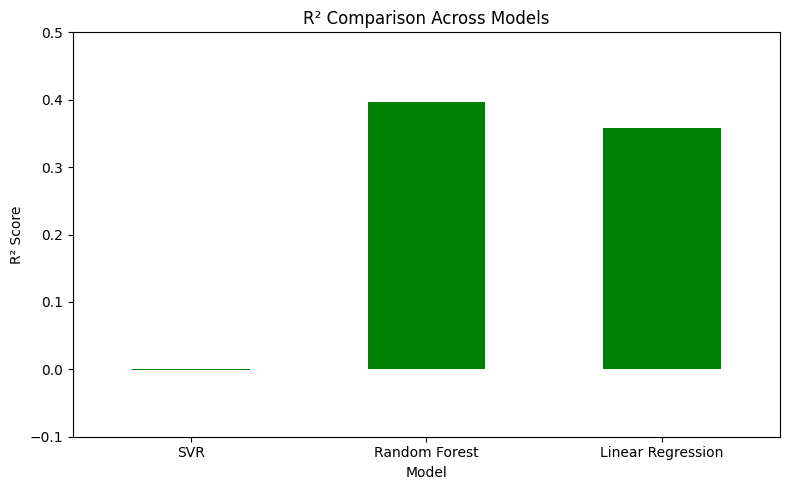

In [30]:
import matplotlib.pyplot as plt

# Assuming metrics_df is already created with columns: Model, MAE, RMSE, R², MAPE
metrics_df.set_index("Model")[["R²"]].plot(
    kind="bar",
    figsize=(8,5),
    color="green",
    legend=False
)

plt.title("R² Comparison Across Models")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.ylim(-0.1, 0.5)  # Adjusted to highlight differences
plt.tight_layout()
plt.show()

## R² Score Comparison

- **SVR (R² ≈ -0.001)**  
  Performs worse than a simple mean baseline, indicating it fails to explain variance in sale prices.

- **Random Forest (R² ≈ 0.396)**  
  Explains ~40% of the variance in sale prices, the strongest performer among the models.

- **Linear Regression (R² ≈ 0.358)**  
  Explains ~36% of the variance, slightly weaker than Random Forest but still a reasonable baseline.

### Key Insight
The R² comparison highlights that **Random Forest** captures the most variance in sale prices, making it the most effective model in this set.  SVR is unsuitable for this dataset, while Linear Regression provides a simpler but moderately effective baseline.

# Final Conclusion

### Exploratory Data Analysis (EDA)
- The dataset contained 2,919 houses with diverse features such as lot size, year built, condition, and sale price.
- SalePrice distribution was positively skewed, with most homes priced around ~200k but several luxury outliers extending beyond 700k.
- Box plots and descriptive statistics confirmed the presence of outliers and skewness, guiding preprocessing decisions.

### Feature Engineering
- Created **HouseAge**, **Renovated**, and **LotSizePerBasement** to capture property age, modernization, and spatial efficiency.
- These engineered features added explanatory power beyond raw variables.

### Multicollinearity (VIF Analysis)
- Identified perfect collinearity between **HouseAge** and **YearBuilt** (infinite VIF).  
- Dropped `YearBuilt` to stabilize regression models.  
- After cleaning, all features had **VIF < 5**, confirming no problematic multicollinearity.

### Correlation Insights
- Strong correlations: `TotalBsmtSF`, `YearBuilt`, and `YearRemodAdd` with `SalePrice`.  
- Negative correlation: `HouseAge` with `SalePrice` (older homes tend to sell for less).  
- Weak correlations: `Id`, `MSSubClass`, `BsmtFinSF2` — limited predictive value.

### Model Training & Evaluation
- **SVR**: Performed poorly (R² ≈ -0.001), unsuitable for this dataset.  
- **Linear Regression**: Moderate performance (R² ≈ 0.358), explains ~36% of variance.  
- **Random Forest**: Best performer (R² ≈ 0.396), capturing ~40% of variance with lower RMSE.  

### Key Takeaways
- **Random Forest** is the recommended model due to its ability to handle non-linear relationships and outperform simpler baselines.  
- Feature engineering and multicollinearity checks improved model stability and interpretability.  
- The workflow demonstrates a complete pipeline: **EDA → Feature Engineering → Data Cleaning → VIF Analysis → Modeling → Evaluation**.  
